In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py

import os
import sys
sys.path.append(os.path.abspath("./"))

print(os.getpid())
%cd ../../

import pylib.mix as mix
import carleman as ca
from matplotlib import colors
plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

17384
c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Carleman/results/"
for i in range(100):
    plt.close()

colors_     = ["blue", "red", "green", "gray", "black"]
linestyles_ = ["-", "--", "--", ":"]


System coefficients:
aa = 1.000
gg = 0.475
eta_x = 1.000
eta_y = 1.000
xi_x = 0.000
xi_y = 0.000

Nt: 256
init. cond.:   0.50   0.50 




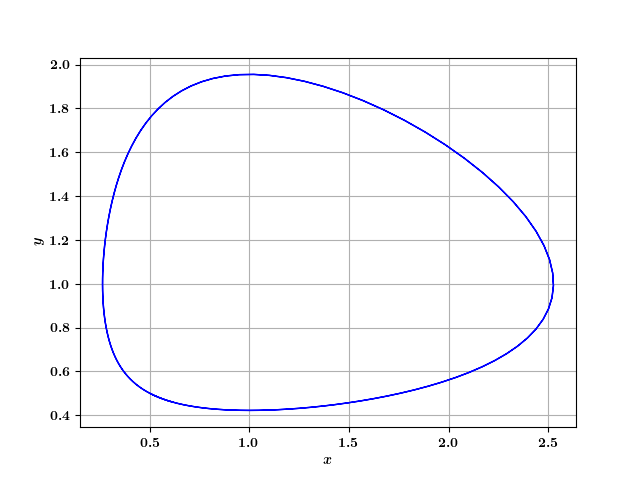

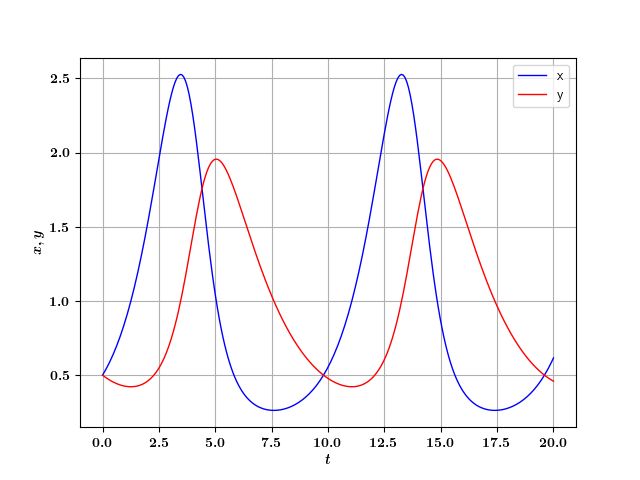

257


In [3]:
# ---------------------------------------------------------------
# --- Prepare the system: Lotka - Volterra 2D ---
# ---------------------------------------------------------------
mix.reload_module(ca)
mix.reload_module(mix)
def choose_case(N_nl, sel_case):
    Nx = 2  # the number of degrees of freedom
    Nx2 = Nx**2 - 1
    F_terms, sys_coefs, return_sys, shift_coefs = None, None, None, None

    # ----------------------------------------------------
    if sel_case == 0:
        x_init = np.array([0.5, 0.5])

        tmax, nt = 20, 8

        # aa, bb, dd, gg = 1.0, 0.1, 1.5, 0.075
        aa, bb, dd, gg = 1.0, 0.1, 1.5, 0.475
        # aa, bb, dd, gg = 2./3., 4./3., 1.0, 1.0

        eta_x, eta_y = 1., 1. 
        # eta_x, eta_y = 4., 2. 

        # F = [
        #     lambda x:   aa * x[0] - bb * x[0] * x[1],
        #     lambda x: - gg * x[1] + dd * x[0] * x[1]
        # ]

        F = [
            lambda x:   aa * x[0] - eta_y * aa * x[0] * x[1],
            lambda x: - gg * x[1] + eta_x * gg * x[0] * x[1]
        ]


        # --- Construct system matrices ---
        # # *** matrix F) ***
        # F_terms[0][1,0] = - c

        # # *** matrix F1 ***
        # F_terms[1][0,1], F_terms[1][1,0] = a, b

    # ----------------------------------------------------
    if sel_case == 1:
        x_init = np.array([0.5, 0.5])

        tmax, nt = 20, 8
        # tmax, nt = 3, 5

        aa, gg = 1.0, 0.475
        eta_x, eta_y = 1., 1. 
        xi_x, xi_y = 0., 0.

        sys_coefs = {}
        sys_coefs["aa"]    = aa
        sys_coefs["gg"]    = gg
        sys_coefs["eta_x"] = eta_x
        sys_coefs["eta_y"] = eta_y
        sys_coefs["xi_x"]  = xi_x
        sys_coefs["xi_y"]  = xi_y

        def return_sys(ss):
            aa    = ss["aa"]       
            gg    = ss["gg"]    
            eta_x = ss["eta_x"] 
            eta_y = ss["eta_y"] 
            xi_x  = ss["xi_x"]  
            xi_y  = ss["xi_y"]  

            F_terms = [None] * (N_nl + 1)
            for ii_nl in range(N_nl + 1):
                F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))
            
            F_terms[0][0,0] =   aa * xi_x - eta_y * aa * xi_x * xi_y
            F_terms[0][1,0] = - gg * xi_y + eta_x * gg * xi_x * xi_y

            F_terms[1][0, 0] = aa - eta_y * aa * xi_y
            F_terms[1][0, 1] =    - eta_y * aa * xi_x

            F_terms[1][1, 0] =        eta_x * gg * xi_y
            F_terms[1][1, 1] = - gg + eta_x * gg * xi_x 

            F_terms[2][0, 1] = - eta_y * aa
            F_terms[2][1, 1] =   eta_x * gg
            return F_terms
        
        def shift_coefs(ss, zeta):
            ss_new = dict(ss)
            ss_new["xi_x"] = ss_new["xi_x"] + zeta[0]
            ss_new["xi_y"] = ss_new["xi_y"] + zeta[1]
            if "xi_z" in ss_new:
                ss_new["xi_z"] = ss_new["xi_z"] + zeta[2]
            return ss_new
        
        print("\nSystem coefficients:")
        for key, value in sys_coefs.items():
            print("{:s} = {:0.3f}".format(key, value))
        print()

        F_terms = return_sys(sys_coefs)
        F = [
            lambda x: F_terms[0][0,0] + F_terms[1][0, 0] * x[0] + F_terms[1][0, 1] * x[1] + F_terms[2][0, 1] * x[0] * x[1],
            lambda x: F_terms[0][1,0] + F_terms[1][1, 0] * x[0] + F_terms[1][1, 1] * x[1] + F_terms[2][1, 1] * x[0] * x[1],
        ]

    # ----------------------------------------------------
    return F, tmax, nt, Nx, x_init, sys_coefs, return_sys, shift_coefs
# ------------------------------------------------------------------------------
sel_case_ = 1

N_nl_orig_ = 2 # formally assume that all considered equations are of the 3-rd order of nonlinearity
F_, tmax_, nt_, Nx_, x_init_ref_, sys_coefs_, return_sys_, shift_coefs_ = choose_case(N_nl_orig_, sel_case = sel_case_)
Nt_ = 1 << nt_
t_ = np.linspace(0, tmax_, Nt_)
dt_ = np.diff(t_)[0]

print("Nt: {:d}".format(Nt_))
print("init. cond.: ", end = "")
mix.print_array(x_init_ref_, ff = [6, 2, "f"])

# --- Standard method (for reference) ---
sol_ref_, t_ref_ = ca.analyse_classical(x_init_ref_, t_, F_)

print(len(t_ref_))

In [9]:
# --------------------------------------------------------------------
# --- Carleman linearization ---
# --------------------------------------------------------------------
mix.reload_module(ca)
N_nl = 6   # should be >= N_nl_orig_

# sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_orig(x_init_ref_, N_nl, N_nl_orig_, t_, return_sys_(sys_coefs_))

# sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_global(
#     x_init_ref_, N_nl, N_nl_orig_, t_, 
#     sys_coefs_, return_sys_, shift_coefs_,
#     zeta_th = 0.1
# )

sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_global_adaptive(
    x_init_ref_, N_nl, N_nl_orig_, t_, 
    sys_coefs_, return_sys_, shift_coefs_,
    zeta_th_init = 0.1,
    error_threshold = 1.e-1,
    eta_err = 1.e-1,
    N_iter_max = 100.
)

The total number of variables in the embedding: 126
--- Shift to another chart, t = 0.069 ---
radius: 0.7
zeta_gl:   0.52   0.49 
xs:      5.178e-01      4.920e-01 
--- Shift to another chart, t = 0.394 ---
radius: 0.1
zeta_gl:   0.61   0.46 
xs:      9.624e-02     -3.200e-02 
--- Shift to another chart, t = 0.719 ---
radius: 0.1
zeta_gl:   0.73   0.44 
xs:      1.206e-01     -2.269e-02 
--- Shift to another chart, t = 0.966 ---
radius: 0.1
zeta_gl:   0.85   0.43 
xs:      1.105e-01     -1.069e-02 
--- Shift to another chart, t = 1.212 ---
radius: 0.1
zeta_gl:   0.97   0.42 
xs:      1.289e-01     -4.566e-03 
--- Shift to another chart, t = 1.458 ---
radius: 0.1
zeta_gl:   1.12   0.42 
xs:      1.489e-01      2.322e-03 
--- Shift to another chart, t = 1.626 ---
radius: 0.1
zeta_gl:   1.24   0.43 
xs:      1.134e-01      6.103e-03 
--- Shift to another chart, t = 1.794 ---
radius: 0.1
zeta_gl:   1.36   0.44 
xs:      1.230e-01      1.033e-02 
--- Shift to another chart, t = 1.962 ---
ra

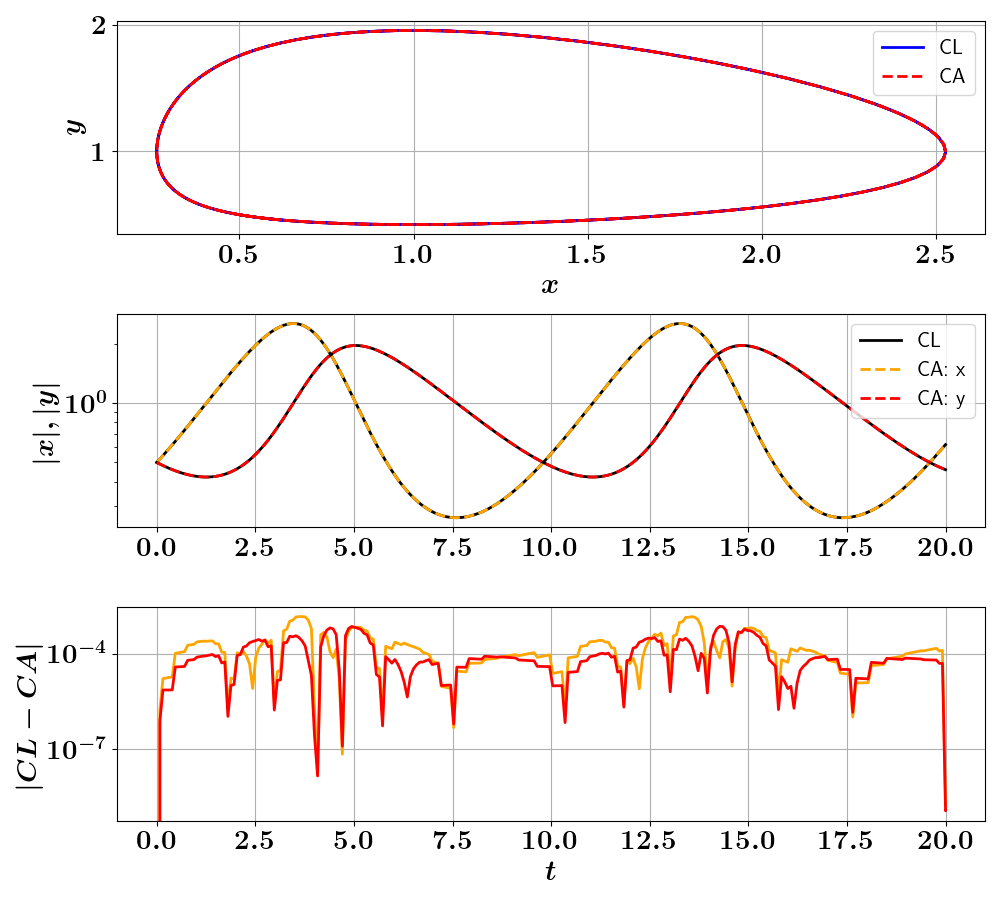

In [10]:
# --------------------------------------------------------------------
# --- Compare trajectories ---
# --------------------------------------------------------------------
mix.reload_module(ca)
ca.compare_trajectory_cl_and_carleman(
    t_ref_, sol_ref_, t_emb_, sol_emb_,
    flag_save=False, path_save=path_save_, 
    case_title = "LV2D", case_emb = case_emb_
)